# Jigsaw Unintended Bias Dataset (v2): Preliminary Exploration
This notebook analyzes the **Jigsaw Unintended Bias in Toxic Comment** [dataset](https://www.kaggle.com/competitions/jigsaw-unintended-bias-in-toxicity-classification/data) to identify which data subsets and features are essential for the model. This data will be used for **initial fine-tuning** to provide the model with a foundational understanding of toxicity patterns before further specialization.

> **Why this dataset?** Unlike the standard **Toxic Comments dataset**, this version includes identity labels. It is essential for ensuring the model does not develop "unintended bias" — for example, learning to flag a comment as toxic simply because it mentions a specific group (e.g., "female" or "black"), even when the context is neutral or positive.

## Importing Dependencies

In [1]:
import warnings

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from toxicity_detector.utils.plotting import *

warnings.filterwarnings("ignore")

pd.set_option("display.max_colwidth", None)

## Loading Data

In [2]:
from toxicity_detector.config import JIGSAW_2

In [3]:
train_df = pd.read_csv(JIGSAW_2["train"])

## 1.0 Data Exploration

In [4]:
train_df.shape

(1804874, 45)

In [5]:
# Count the number of non-toxic and toxic comments
non_toxic_count = train_df[train_df["target"] < 0.5].shape[0]
toxic_count = train_df[train_df["target"] >= 0.5].shape[0]
print(f"Non-toxic comments: {non_toxic_count}")
print(f"Toxic comments: {toxic_count}")

Non-toxic comments: 1660540
Toxic comments: 144334


In [6]:
train_df.isnull().sum().any()

np.True_

In [7]:
# Removing empty comments
train_df = train_df[train_df["comment_text"].notnull()]
train_df.shape

(1804871, 45)

In [8]:
train_df = train_df.rename(columns={"target": "toxicity"})
train_df.columns

Index(['id', 'toxicity', 'comment_text', 'severe_toxicity', 'obscene',
       'identity_attack', 'insult', 'threat', 'asian', 'atheist', 'bisexual',
       'black', 'buddhist', 'christian', 'female', 'heterosexual', 'hindu',
       'homosexual_gay_or_lesbian', 'intellectual_or_learning_disability',
       'jewish', 'latino', 'male', 'muslim', 'other_disability',
       'other_gender', 'other_race_or_ethnicity', 'other_religion',
       'other_sexual_orientation', 'physical_disability',
       'psychiatric_or_mental_illness', 'transgender', 'white', 'created_date',
       'publication_id', 'parent_id', 'article_id', 'rating', 'funny', 'wow',
       'sad', 'likes', 'disagree', 'sexual_explicit',
       'identity_annotator_count', 'toxicity_annotator_count'],
      dtype='object')

In [9]:
toxicity_columns = ["toxicity", "severe_toxicity", "obscene", "threat", "insult", "identity_attack"]
main_categories = ["male", "female", "homosexual_gay_or_lesbian", "christian", "jewish", "muslim", "black", "white", "psychiatric_or_mental_illness"]  # categories with highest prevalence
other_categories = ["sexual_explicit", "transgender", "other_disability", "other_gender", "heterosexual", "bisexual", "other_sexual_orientation", "buddhist", "hindu", "atheist", "other_religion", "physical_disability", "intellectual_or_learning_disability", "other_race_or_ethnicity", "asian", "latino"]  # categories with lowest prevalence

In [10]:
# Removing unused columns
train_df = train_df[["id", "comment_text"] + toxicity_columns + main_categories]
train_df.shape

(1804871, 17)

The labels in this dataset (e.g., `target`, `insult`) are fractional values representing rater consensus. To prepare the data for binary classification, I am applying a threshold of 0.5: any value $\ge 0.5$ is mapped to `1` (positive), and values below $0.5$ are mapped to `0` (negative). This follows the standard evaluation logic used in the original Kaggle competition.

In [11]:
for column in toxicity_columns + main_categories:
    train_df[column] = train_df[column].apply(lambda x: 1 if x >= 0.5 else 0)
    
train_df.describe()

,id,toxicity,severe_toxicity,obscene,threat,insult,identity_attack,male,female,homosexual_gay_or_lesbian,christian,jewish,muslim,black,white,psychiatric_or_mental_illness
count,1.804871e+06,1.804871e+06,1.804871e+06,1.804871e+06,1.804871e+06,1.804871e+06,1.804871e+06,1.804871e+06,1.804871e+06,1.804871e+06,1.804871e+06,1.804871e+06,1.804871e+06,1.804871e+06,1.804871e+06,1.804871e+06
mean,3.738433e+06,7.996915e-02,7.202731e-06,5.320602e-03,2.371361e-03,5.902583e-02,7.429894e-03,2.464664e-02,2.960267e-02,6.092956e-03,2.239661e-02,4.239084e-03,1.163850e-02,8.255992e-03,1.389684e-02,2.708781e-03
std,2.445187e+06,2.712455e-01,2.683781e-03,7.274817e-02,4.863886e-02,2.356731e-01,8.587604e-02,1.550458e-01,1.694885e-01,7.781925e-02,1.479697e-01,6.497012e-02,1.072523e-01,9.048666e-02,1.170629e-01,5.197543e-02
min,5.984800e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,7.969740e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,5.223774e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,5.769854e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.334010e+06,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


In [12]:
toxic_df = train_df[train_df[toxicity_columns].sum(axis=1) > 0]
toxic_df.shape

(147963, 17)

In [13]:
# Number of toxic comments with identity categories
toxic_df[toxic_df[main_categories].sum(axis=1) > 0].shape

(28276, 17)

In [14]:
# Identity rich but non-toxic comments
identity_df = train_df[(train_df[toxicity_columns].sum(axis=1) == 0) & (train_df[main_categories].sum(axis=1) > 0)]
identity_df.shape

(135534, 17)

In [15]:
plain_non_toxic_df = train_df[(train_df[toxicity_columns].sum(axis=1) == 0) & (train_df[main_categories].sum(axis=1) == 0)]
plain_non_toxic_df.shape

(1521374, 17)

In [16]:
# Selecting a portion of plain non-toxic comments to reduce the size of the dataset
plain_non_toxic_df = plain_non_toxic_df.sample(n=100000, random_state=42)

### 1.1 Analyzing Toxicity Categories

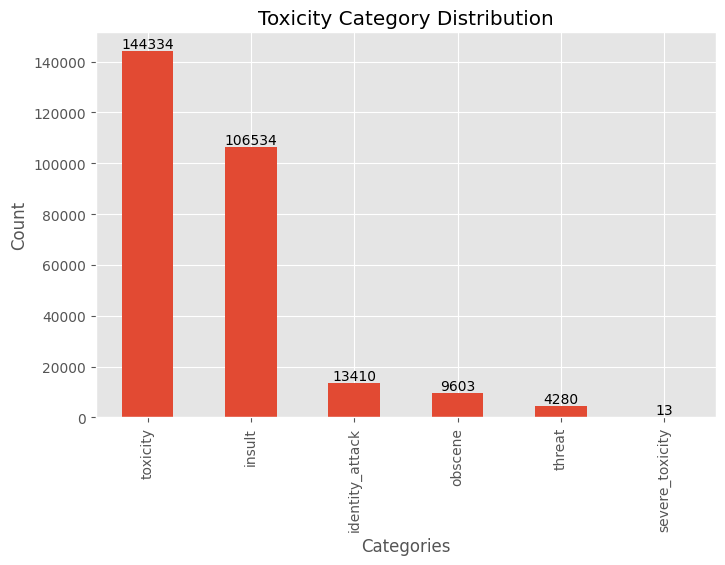

In [17]:
plot_category_distribution(toxic_df, toxicity_columns, "Toxicity Category Distribution", figsize=(8, 5))

**Note:** The **Unintended Bias Dataset** has very few examples labeled as `severe_toxicity`. Therefore, we won't utilize that column for this dataset.

In [18]:
toxicity_columns.remove("severe_toxicity")

In [19]:
# Distribution of number of toxicity labels per comment
toxic_df["label_count"] = toxic_df[toxicity_columns].sum(axis=1)
toxic_df[toxic_df["label_count"] > 0]["label_count"].value_counts().sort_index()

label_count
1     27936
2    110249
3      9393
4       377
5         8
Name: count, dtype: int64

In [20]:
toxic_df["category_count"] = toxic_df[main_categories].sum(axis=1)
toxic_df["category_count"].value_counts().sort_index()

category_count
0    119687
1     18474
2      7302
3      1952
4       442
5        80
6        22
7         4
Name: count, dtype: int64

In [21]:
identity_df["category_count"] = identity_df[main_categories].sum(axis=1)
identity_df["category_count"].value_counts().sort_index()

category_count
1    97968
2    30556
3     5766
4     1047
5      164
6       19
7       12
8        2
Name: count, dtype: int64

In [22]:
# Analyzing what toxicity columns co-occur most frequently
co_occurrence_matrix = train_df[toxicity_columns].T.dot(train_df[toxicity_columns])
co_occurrence_matrix

,toxicity,obscene,threat,insult,identity_attack
toxicity,144334,9419,4171,104154,12427
obscene,9419,9603,102,5204,298
threat,4171,102,4280,518,273
insult,104154,5204,518,106534,4204
identity_attack,12427,298,273,4204,13410


In [23]:
# Analyzing how often each toxicity column co-occurs with only "toxicity" label
co_occurrence = pd.Series(dtype=int, index=toxicity_columns)

for col in toxicity_columns:
    co_occurrence[col] = toxic_df[(toxic_df[col] == 1) & (toxic_df["toxicity"] == 1) & (toxic_df["label_count"] == 2)].shape[0]

co_occurrence

toxicity           110222.0
obscene              4162.0
threat               3408.0
insult              94647.0
identity_attack      8005.0
dtype: float64

### 1.2 Identity-Focused Analysis

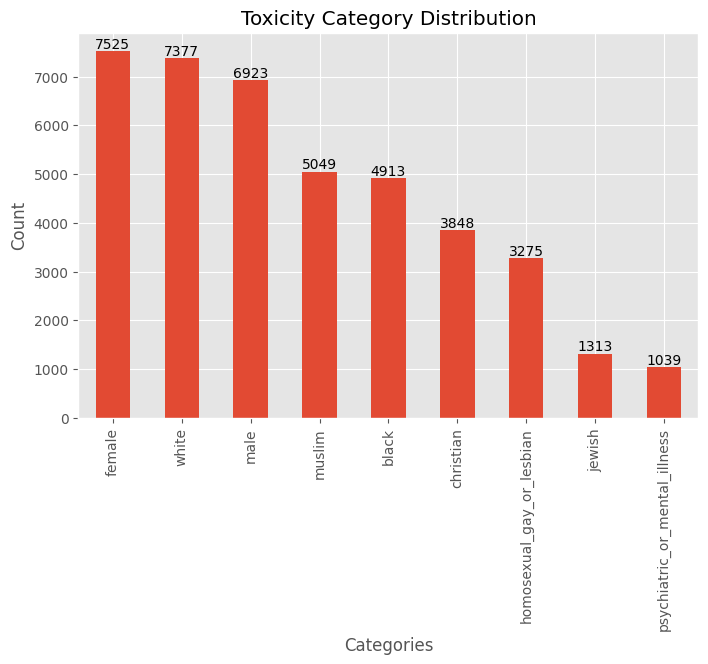

In [24]:
plot_category_distribution(toxic_df, main_categories, "Toxicity Category Distribution")

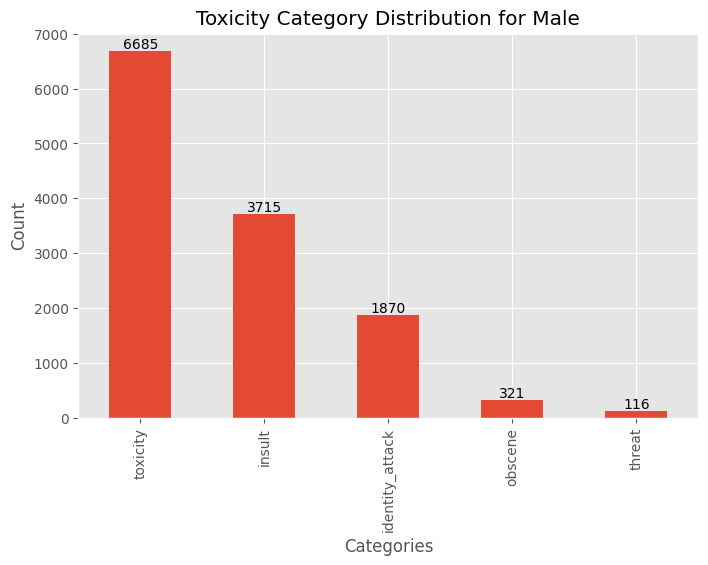

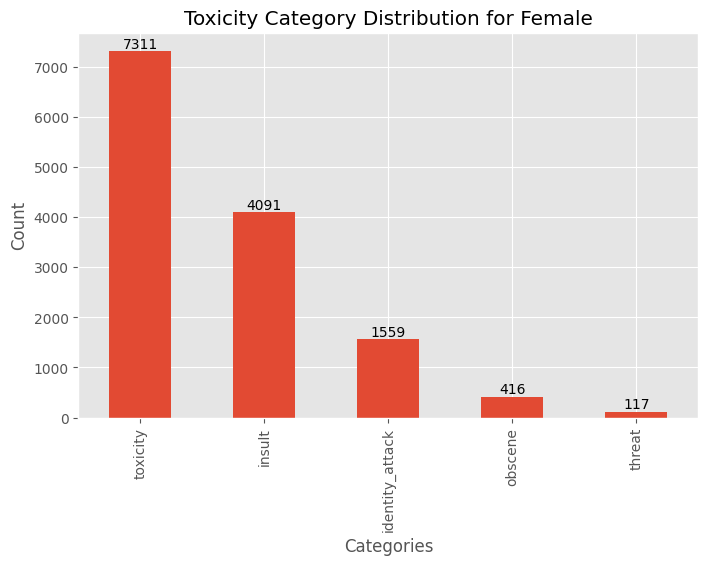

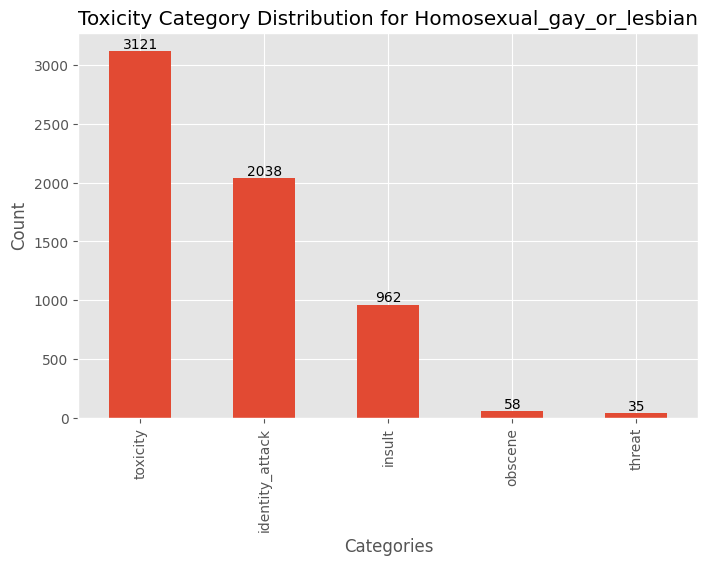

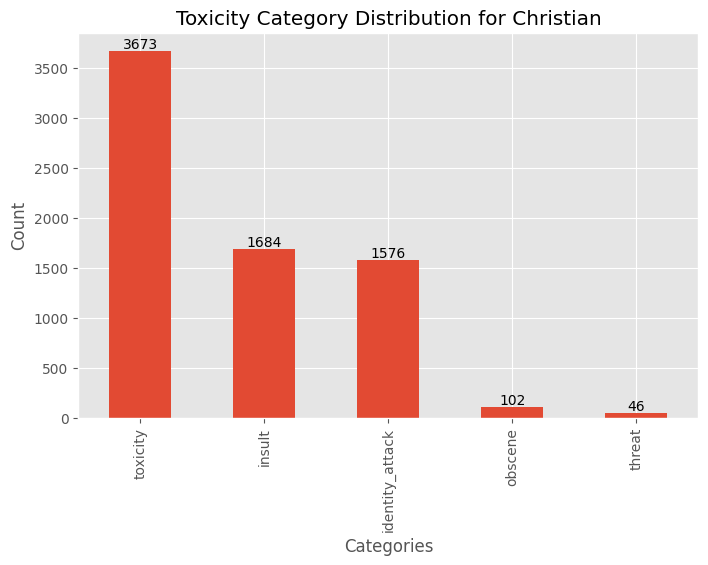

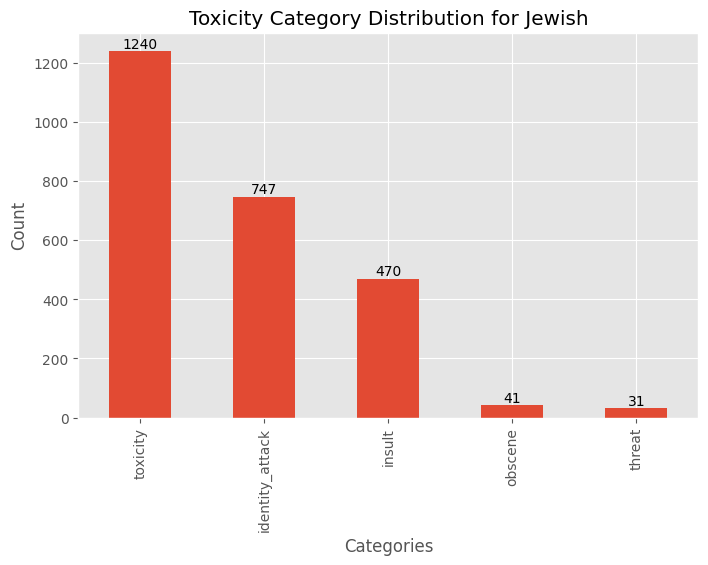

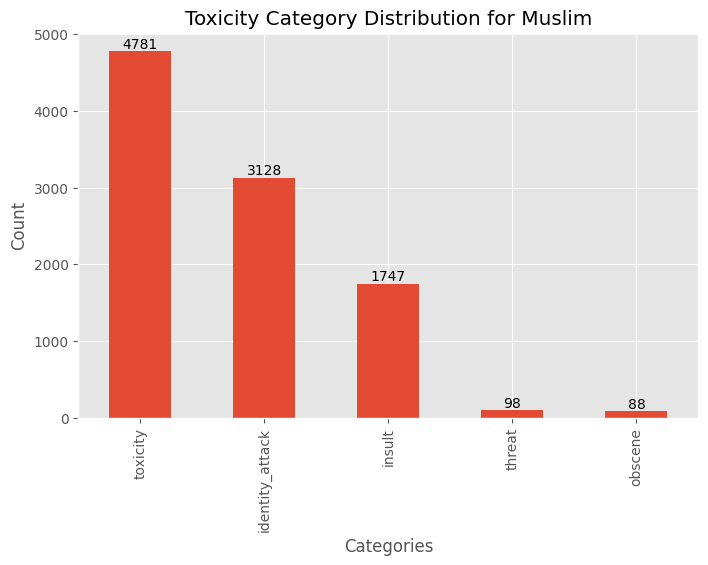

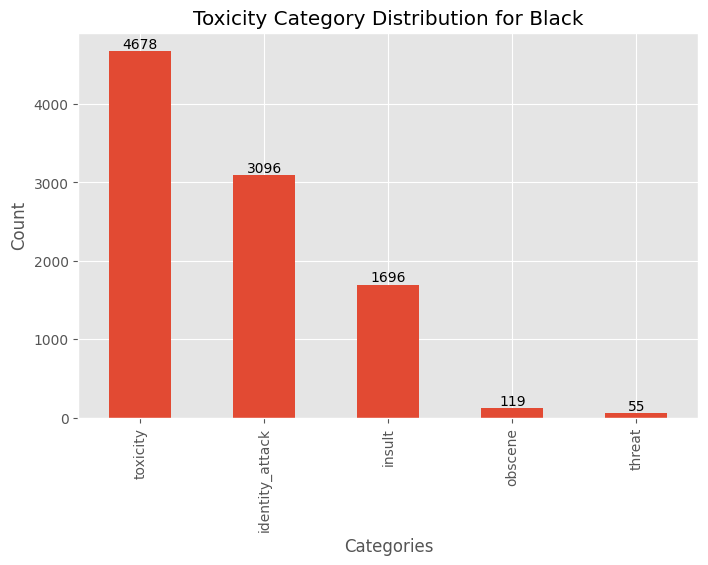

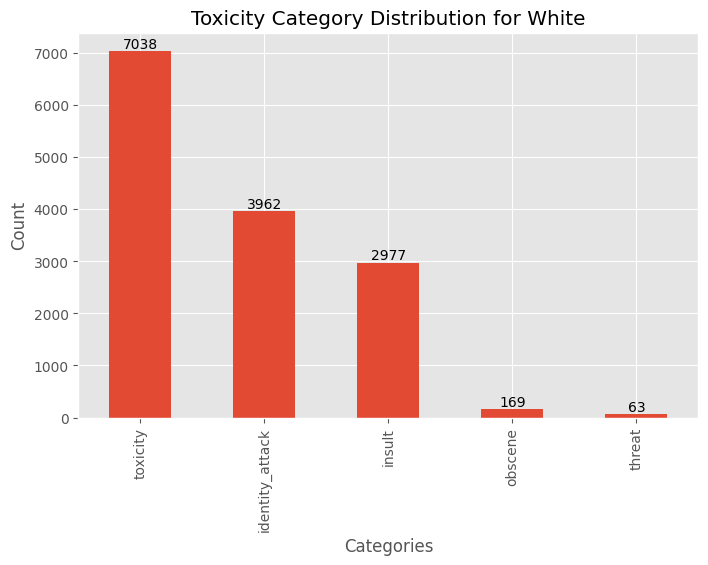

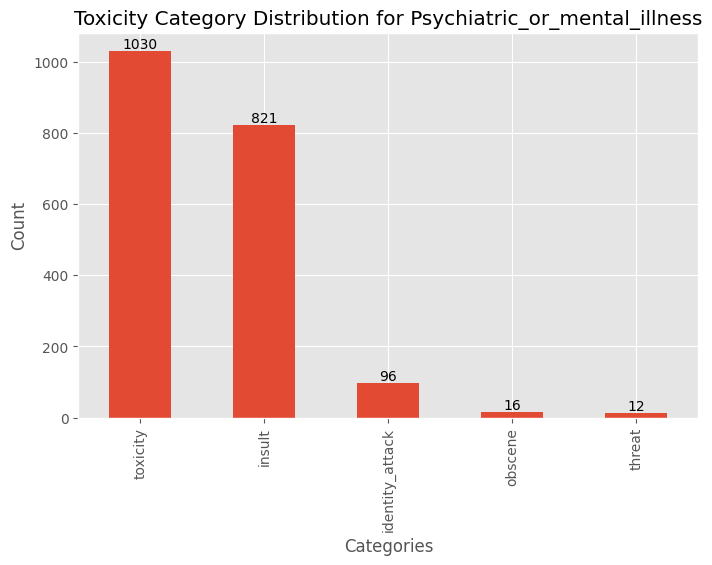

In [25]:
for category in main_categories:
    category_df = toxic_df[toxic_df[category] == 1]
    plot_category_distribution(category_df, toxicity_columns, f"Toxicity Category Distribution for {category.capitalize()}", figsize=(8, 5))

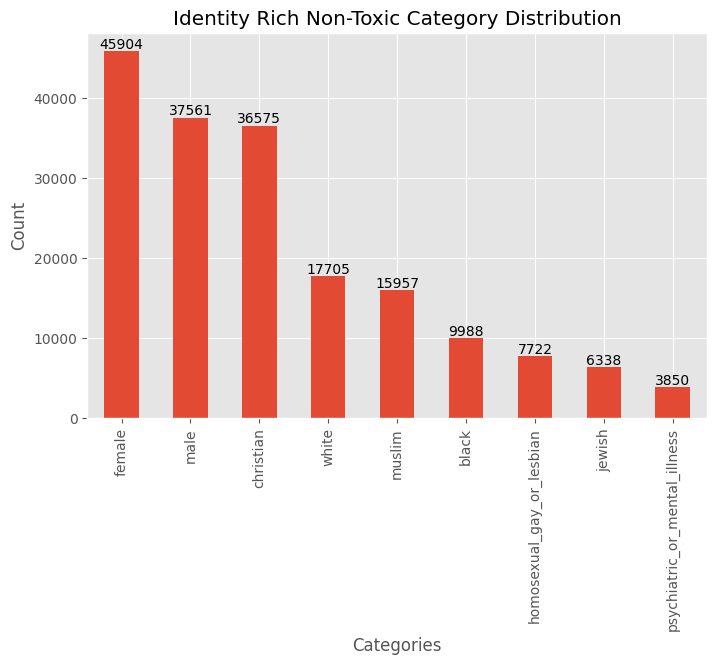

In [26]:
plot_category_distribution(identity_df, main_categories, "Identity Rich Non-Toxic Category Distribution")

### 1.3 Exploring the Lengths of the Comments

In [27]:
def count_comment_length(df):
    return df["comment_text"].apply(lambda x: len(x.split()))

In [28]:
toxic_df["comment_length"] = count_comment_length(toxic_df)
identity_df["comment_length"] = count_comment_length(identity_df)
plain_non_toxic_df["comment_length"] = count_comment_length(plain_non_toxic_df)

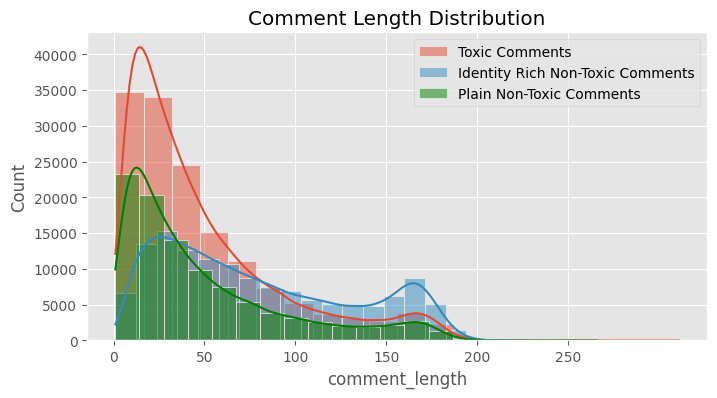

In [29]:
plt.figure(figsize=(8, 4))
sns.histplot(toxic_df["comment_length"], label="Toxic Comments", fill=True, bins=20, alpha=0.5, kde=True)
sns.histplot(identity_df["comment_length"], label="Identity Rich Non-Toxic Comments", fill=True, bins=20, alpha=0.5, kde=True)
sns.histplot(plain_non_toxic_df["comment_length"], label="Plain Non-Toxic Comments", fill=True, bins=20, alpha=0.5, kde=True, color="green")

plt.xticks(range(0, 251, 50))
plt.legend()
plt.title("Comment Length Distribution")
plt.show()

## 2.0 Export: Final Saving of the Dataset

In [30]:
df = pd.concat([toxic_df, identity_df, plain_non_toxic_df])
df.shape

(383497, 20)

In [31]:
df.to_csv(JIGSAW_2["combined"], index=False)